# Validación y análisis de sensibilidad

**Proyecto:** Optimización de rutas de autobuses intersectoriales en la GAM

**Objetivo:** comprobar la optimalidad de los dos modelos y estudiar si sus conclusiones cambian ante los principales supuestos del análisis.

## 1. Metodología de validación

Este proyecto de investigación no entrena un modelo con una variable objetivo observada. Por lo tanto, una validación cruzada tradicional no aplica. En cambio, se utiliza un esquema equivalente para problemas de optimización:

1. Se cargan los resultados exportados durante la comparación de los modelos y se reconstruye la selección de $\lambda$ con el mismo criterio determinista.
2. Se conservan los tres pares originales y se seleccionan 30 pares aleatorios adicionales comprobando que exista un camino dirigido.
3. A* bidireccional y Dijkstra resuelven cada par con el costo de menor tiempo y con el costo ajustado por variabilidad.
4. Los costos obtenidos por ambos algoritmos deben coincidir dentro de una tolerancia de $10^{-6}$ minutos.
5. Las rutas de ambos modelos se evalúan con la misma semilla, el mismo número de réplicas y los mismos supuestos probabilísticos.
6. Los modelos se comparan sobre los 30 pares adicionales mediante media, desviación estándar, percentil 90 e índice de confiabilidad.

El índice de confiabilidad se define como:

$$IC=\frac{1}{S}\sum_{s=1}^{S}\mathbb{I}\left(T_R^{(s)}\leq1.15\overline{T}_R\right)\times100.$$

Este índice describe la estabilidad de cada ruta dentro de su distribución simulada. Dijkstra se utiliza como control de optimalidad, mientras que la validación combina la verificación algorítmica con la evaluación de las rutas mediante simulación.

In [1]:
from pathlib import Path
import sys

for candidata in (Path.cwd(), *Path.cwd().parents):
    if (candidata / "rutas_gam").exists():
        RAIZ = candidata
        break
else:
    raise FileNotFoundError("Ejecute este notebook dentro del repositorio clonado.")

sys.path.insert(0, str(RAIZ))
DATOS_RAW = RAIZ / "data" / "raw"
DATOS_PROCESADOS = RAIZ / "data" / "processed"
FIGURAS = RAIZ / "figuras"
FIGURAS.mkdir(exist_ok=True)

import matplotlib.pyplot as plt
from IPython.display import display

import rutas_gam as rg

SEMILLA = 2026
VALORES_LAMBDA = tuple(indice * 0.5 for indice in range(21))
print("Configuración reproducible lista. Semilla:", SEMILLA)

Configuración reproducible lista. Semilla: 2026


## 2. Pares originales y muestra adicional

Los pares adicionales complementan los casos originales y permiten evaluar ambos modelos sobre una muestra más amplia de recorridos. La muestra se selecciona entre nodos de la red vial para ampliar la validación algorítmica y comprobar si los resultados se mantienen más allá de los tres pares iniciales.

In [2]:
configuraciones = [
    ("Estadio Oeste → San Pedro", "Estadio Oeste", "San Pedro - Carmiol"),
    ("Cuatro Reinas → Paso Ancho", "Terminal Cuatro Reinas", "Parada El Caracol"),
    ("Hatillo → Curridabat", "Periférica Hatillo", "Plaza del Sol"),
]
preparacion = rg.preparar_validacion_ampliada(
    DATOS_RAW / "red_san_jose.graphml",
    DATOS_PROCESADOS / "paradas_importantes.csv",
    DATOS_PROCESADOS / "puntos_estudio.csv",
    DATOS_PROCESADOS / "comparacion_modelos.csv",
    configuraciones,
    VALORES_LAMBDA,
    cantidad_adicional=30,
    semilla=SEMILLA,
)
grafo_crudo, grafo = preparacion.grafo_crudo, preparacion.grafo
casos_originales = preparacion.casos_originales
casos_adicionales = preparacion.casos_adicionales
casos_validacion = preparacion.casos_validacion
LAMBDA_RIESGO = preparacion.lambda_riesgo

print("Pares originales:", len(casos_originales))
print("Pares adicionales:", len(casos_adicionales))
print("Lambda reconstruido desde el criterio de selección:", LAMBDA_RIESGO)

Pares originales: 3
Pares adicionales: 30
Lambda reconstruido desde el criterio de selección: 6.5


## 3. Coincidencia de A* y Dijkstra

Para el Modelo 1 se valida el costo temporal de cada arco, $t_{ij}$.

Para el Modelo 2 se valida el costo ajustado por variabilidad:

$$c_{ij}^{(2)}=t_{ij}+\lambda t_{ij}\sqrt{e^{\sigma_{vía}^{2}}-1},\qquad \lambda=6.5.$$

El valor de $\lambda$ se obtiene aplicando el mismo criterio utilizado durante la comparación determinista: seleccionar el menor valor positivo evaluado que modifica al menos una de las tres rutas originales. Los resultados se contrastan con los exportados durante la comparación principal para mantener la continuidad entre ambas etapas.

La coincidencia entre A* y Dijkstra se verifica con una tolerancia de $10^{-6}$ minutos. Además, se registra si el criterio ajustado por variabilidad selecciona una secuencia de arcos diferente.

In [3]:
resultado_validacion = rg.ejecutar_validacion_ampliada(
    preparacion, repeticiones=1000, semilla=SEMILLA
)
validacion = resultado_validacion.tabla
rutas_validacion = resultado_validacion.rutas
resumen_validacion = resultado_validacion.resumen_muestras
comparacion_validacion = resultado_validacion.comparacion_modelos

display(resumen_validacion)
display(rg.tabla_validacion_original(validacion))
display(rg.tabla_validacion_adicional(comparacion_validacion))
print("Los resultados originales coinciden con la comparación exportada.")

,muestra,pares,rutas_diferentes
0,Original,3,1
1,Adicional,30,11


,Par,Modelo,Tiempo determinista (min),Media simulada (min),Percentil 90 (min),Ruta diferente
0,Estadio Oeste → San Pedro,Menor tiempo,9.96,10.00,12.06,True
1,Cuatro Reinas → Paso Ancho,Menor tiempo,8.22,8.26,10.04,False
2,Hatillo → Curridabat,Menor tiempo,8.98,8.93,10.75,False
33,Estadio Oeste → San Pedro,Ajustada por variabilidad,9.98,10.03,12.07,True
34,Cuatro Reinas → Paso Ancho,Ajustada por variabilidad,8.22,8.26,10.04,False
35,Hatillo → Curridabat,Ajustada por variabilidad,8.98,8.93,10.75,False


,Modelo,Pares,Rutas diferentes,Tiempo determinista promedio (min),Media simulada promedio (min),Desviación promedio (min),Percentil 90 promedio (min),IC promedio (%)
1,Menor tiempo,30,11,6.36,6.37,0.98,7.66,83.57
3,Ajustada por variabilidad,30,11,6.44,6.45,1.00,7.76,83.58


Los resultados originales coinciden con la comparación exportada.


**Tabla de validación:**

- Una diferencia dentro de la tolerancia numérica confirma que A* y Dijkstra obtienen el mismo costo óptimo.

- El número de rutas diferentes indica cuántos pares modifican su recorrido al incorporar la penalización por variabilidad.

Con $\lambda=6.5$, el Modelo 2 selecciona una ruta diferente en 1 de los 3 pares originales y en 11 de los 30 pares adicionales.

### 3.1 Comparación cuantitativa sobre los pares adicionales

La tabla agregada compara ambos modelos sobre los mismos 30 pares y bajo el mismo procedimiento Monte Carlo.

* El Modelo 1 obtiene una media simulada promedio de $6.37$ minutos y un percentil 90 promedio de $7.66$ minutos. 
* El Modelo 2 obtiene $6.45$ y $7.76$ minutos, respectivamente. 

La desviación promedio pasa de $0.98$ a $1.00$ minutos y el índice de confiabilidad permanece prácticamente igual: $83.57\%$ frente a $83.58\%$.

Con los datos y supuestos actuales se selecciona el **Modelo 1** *(camino de menor tiempo)* como resultado principal. Ya que presenta menores tiempos deterministas y simulados sin una pérdida relevante de confiabilidad. 

**El Modelo 2** se conserva como análisis complementario porque demuestra cómo una penalización explícita puede cambiar 11 de los 30 recorridos, pero no produce una mejora cuantitativa en las métricas simuladas. Esta elección es válida únicamente dentro de la investigación de flujo libre y con el alcance actual no constituye evidencia sobre desempeño real en tráfico.

## 4. Análisis de sensibilidad

Los tres supuestos se modifican por separado y se mantienen los mismos pares originales para que cada cambio pueda atribuirse al supuesto analizado. La comparación de $\lambda$ amplía la selección determinista realizada anteriormente, aquí también se observan las métricas Monte Carlo de las rutas resultantes.

- **Riesgo:** valores de $\lambda$ entre $0$ y $10$ con incrementos de $0.5$.
- **Velocidades imputadas:** $f_v\in\{0.85,1.00,1.15\}$.
- **Réplicas:** $S\in\{200,1000,5000\}$.

En todos los casos se observan el tiempo medio, la desviación, el percentil 90 y el índice de confiabilidad.

### 4.1 Analisis de Riesgo lambda

In [4]:
analisis_lambda = rg.analizar_sensibilidad_lambda(
    grafo, casos_originales, VALORES_LAMBDA,
    repeticiones=1000, semilla=SEMILLA,
)
sens_lambda = analisis_lambda.detalle
resumen_lambda = analisis_lambda.resumen
display(resumen_lambda.round(3))

,lambda_riesgo,pares,rutas_diferentes,tiempo_medio_min,desviacion_media_min,p90_medio_min,IC_medio_pct
0,0.0,3,0,9.064,1.431,10.948,83.700
1,0.5,3,0,9.064,1.431,10.948,83.700
2,1.0,3,0,9.064,1.431,10.948,83.700
3,1.5,3,0,9.064,1.431,10.948,83.700
4,2.0,3,0,9.064,1.431,10.948,83.700
5,2.5,3,0,9.064,1.431,10.948,83.700
6,3.0,3,0,9.064,1.431,10.948,83.700
7,3.5,3,0,9.064,1.431,10.948,83.700
8,4.0,3,0,9.064,1.431,10.948,83.700
9,4.5,3,0,9.064,1.431,10.948,83.700


**Resultado observado:** 
* Con $\lambda=0$ desaparece la penalización y el segundo modelo reproduce el camino de menor tiempo. 
* Los tres recorridos se mantienen hasta $\lambda=6$.
* Con $\lambda=6.5$ cambia *Estadio Oeste → San Pedro* 
* Con $\lambda=10$ cambian dos de los tres pares.

Esto confirma que la decisión es estable ante penalizaciones moderadas, pero puede modificarse cuando se asigna una importancia mayor a la variabilidad.

### 4.2 Analisis de Velocidades imputadas

In [5]:
analisis_velocidades = rg.analizar_sensibilidad_velocidades(
    grafo_crudo, casos_originales, factores=(0.85, 1.0, 1.15),
    lambda_riesgo=LAMBDA_RIESGO, repeticiones=1000, semilla=SEMILLA,
)
sens_velocidades = analisis_velocidades.detalle
resumen_velocidades = analisis_velocidades.resumen
display(resumen_velocidades.round(3))

,factor_velocidad_imputada,modelo,pares,tiempo_medio_min,desviacion_media_min,p90_medio_min,IC_medio_pct,rutas_diferentes
0,0.85,Menor tiempo,3,9.595,1.516,11.590,83.733,2
1,0.85,Ajustada por variabilidad,3,10.140,1.599,12.217,83.900,2
2,1.00,Menor tiempo,3,9.064,1.431,10.948,83.700,1
3,1.00,Ajustada por variabilidad,3,9.074,1.433,10.951,83.733,1
4,1.15,Menor tiempo,3,8.668,1.369,10.460,83.733,1
5,1.15,Ajustada por variabilidad,3,8.681,1.370,10.470,83.800,1


**Resultado observado:** El factor solo modifica las velocidades que faltaban en OSM. Al pasar de $0.85$ a $1.15$, el tiempo medio disminuye aproximadamente $0.93$ minutos en el Modelo 1 y $1.46$ minutos en el Modelo 2. 

Con $\lambda=6.5$, cambian dos pares cuando el factor es $0.85$ y un par cuando se utiliza $1.00$ o $1.15$. La magnitud de los tiempos y la selección de algunas rutas son sensibles a la imputación; esta es una limitación relevante mientras no existan velocidades observadas.

### 4.3 Analisis de Replicas

In [6]:
analisis_replicas = rg.analizar_sensibilidad_replicas(
    grafo, casos_originales, valores=(200, 1000, 5000),
    lambda_riesgo=LAMBDA_RIESGO, semilla=SEMILLA,
)
sens_replicas = analisis_replicas.detalle
resumen_replicas = analisis_replicas.resumen
display(resumen_replicas.round(3))

,repeticiones,modelo,pares,tiempo_medio_min,desviacion_media_min,p90_medio_min,IC_medio_pct
0,200,Menor tiempo,3,9.088,1.480,11.019,84.000
1,200,Ajustada por variabilidad,3,9.096,1.480,11.018,84.167
2,1000,Menor tiempo,3,9.064,1.431,10.948,83.700
3,1000,Ajustada por variabilidad,3,9.074,1.433,10.951,83.733
4,5000,Menor tiempo,3,9.051,1.387,10.871,83.933
5,5000,Ajustada por variabilidad,3,9.060,1.388,10.883,83.920


**Resultado observado:** 
* La ruta no se vuelve a escoger a partir de la simulación. 
* Entre $1.000$ y $5.000$ réplicas, la media agregada cambia cerca de $0.01$ minutos y el percentil 90 cerca de $0.08 minutos$.
+ Las métricas son razonablemente estables y para $1.000$ escenarios resultan suficientes para esta comparación inicial.

### 4.4 Analisis de sensibilidad

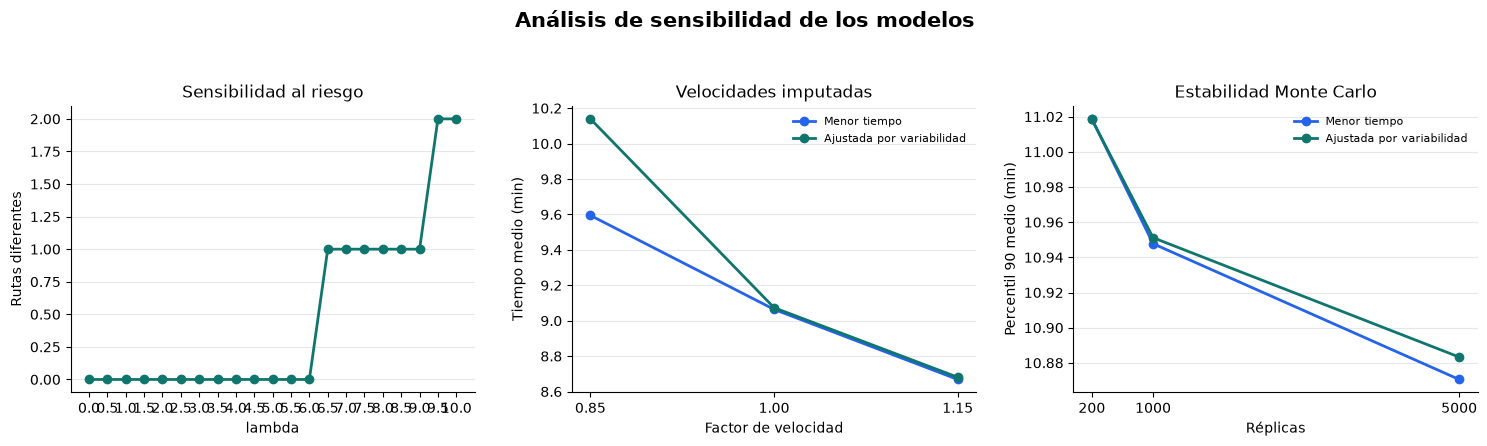

In [7]:
rg.graficar_sensibilidad_modelos(
    resumen_lambda, resumen_velocidades, resumen_replicas,
    VALORES_LAMBDA, FIGURAS / "07_sensibilidad_modelos.png",
)
plt.show()

## 5. Resultados, alcance y limitaciones

La evidencia debe interpretarse dentro del alcance definido ya que los tiempos son teóricos y representan condiciones de flujo libre dado que el ancance de esta estapa de investigación es exclusivamente teórica. Por esto, las dispersiones por clase vial son supuestos de simulación, no estimaciones obtenidas de tráfico observado. Y el factor general representa condiciones compartidas, como lluvia o mayor tránsito, pero no interviene en la selección porque multiplica por igual los arcos de una ruta dentro de cada réplica lo cual puede tener un comportamiento distinto en el mundo real.

Por otro lado, la comparación utiliza la misma semilla y los mismos supuestos probabilísticos para ambos modelos. Esto proporciona un procedimiento reproducible y un factor general común; sin embargo, los multiplicadores locales se generan a lo largo de cada recorrido y no constituyen una realización completa de tráfico para todos los arcos de la red. Por tanto, la expresión *mismos escenarios* se limita al diseño Monte Carlo compartido y no implica una observación simultánea de toda la red.

El índice de confiabilidad es relativo a la propia media simulada de cada ruta. Sirve para describir su dispersión interna, pero no equivale a una probabilidad empírica de puntualidad. Asimismo, los 30 pares adicionales son pares sintéticos de nodos viales que permiten ampliar la comprobación algorítmica, pero no representan demanda, viajes observados ni paradas oficiales. 

Una ruta ajustada por variabilidad no equivale a un recorrido oficial ni garantiza un mejor desempeño real. Los datos de **OSM** puede presentar cobertura desigual en límites de velocidad y destinos, mientras que los datos del **INEC** están agregados y no contienen información personal. Bajo estas limitaciones, la comparación favorece al Modelo 1 y conserva el Modelo 2 como análisis exploratorio de sensibilidad. Por todo esto, los resultados no deben utilizarse por sí solos para decisiones operativas o de inversión.

In [9]:
resumen_sensibilidad = rg.exportar_resultados_validacion(
    resultado_validacion, analisis_lambda, analisis_velocidades,
    analisis_replicas, DATOS_PROCESADOS,
)
print(
    "Guardados validacion_modelos.csv, comparacion_validacion.csv "
    "y sensibilidad_modelos.csv"
)

Guardados validacion_modelos.csv, comparacion_validacion.csv y sensibilidad_modelos.csv


## 6. Recomendaciones para una etapa futura

Una siguiente etapa de la investigación debería incorporar datos observados para estimar los tiempos y la variabilidad de cada tramo. Se recomienda recopilar o utilizar registros publicos de GPS de autobuses, tiempos reales de viaje, condiciones de tráfico y factores como horario, día de la semana y clima. Estos datos permitirían sustituir los tiempos de flujo libre por estimaciones representativas de la realidad vial.

También conviene integrar los recorridos oficiales, paradas, horarios y frecuencias del transporte público. De esta manera, las rutas calculadas podrían compararse con trayectos existentes y considerar tiempos de espera, transbordos y restricciones operativas.

La demanda puede estudiarse mediante información agregada de ascensos y descensos, matrices origen–destino o encuestas de movilidad. Esto permitiría seleccionar pares según su importancia real y evaluar si las rutas propuestas benefician los desplazamientos con mayor demanda.

Con observaciones suficientes, las dispersiones por clase vial podrían reemplazarse por variabilidades estimadas para cada tramo. El parámetro $\lambda$ también podría calibrarse según el equilibrio observado entre tiempo y confiabilidad, en lugar de seleccionarse mediante un criterio exploratorio.

Finalmente, los modelos deberían validarse con períodos o recorridos que no participen en su calibración. La comparación podría utilizar métricas como error absoluto medio, cobertura de intervalos, puntualidad y tiempo de viaje observado. Esta ampliación permitiría pasar de una investigación metodológica inicial a una herramienta de apoyo para la planificación del transporte público.